## 環境設置

In [1]:
try:
    import openseespy.opensees as ops  # noqa: F401
except ImportError:
    import sys
    !{sys.executable} -m pip install -q openseespy
    import openseespy.opensees as ops  # noqa: F401

# Case-06.5:完整 2 層樓框架 V-Δ 側推分析 + 真正的 FEMA 273

依 [ROADMAP.md](../ROADMAP.md) 規劃,這是 Case-06「尚待」清單裡最後
一項——之前 Case-06 全部都是**單一斷面或單根懸臂柱**層級的驗證
(彎矩-曲率、P-M 交互作用圖、lumped hinge)。這裡第一次把 Case-06
驗證過的纖維斷面,接上 Case-04.5 已經驗證過的真實構架幾何(Y 向,
1 跨 2 柱),跑**完整結構**的側推分析,拿到真正的 V-Δ(側向力-位移)
曲線——**這才是 FEMA 273 等面積雙直線法原本設計要用在的對象**,
不是之前 Case-06 第 6/8 課用在單一斷面 M-φ 上的那個預演版本。

**沿用哪些已驗證的東西,不重新發明**:
- 構架幾何、梁斷面、樓層力(F1_Y/F2_Y):Case-04.5
- 柱纖維斷面(圍束核心+未圍束保護層,Mander 公式):Case-06
- 演算法 fallback:Case-06 共用函式
- 等面積雙直線法(正確聯立解版本,不是簡化猜測版):上次修正過的邏輯

## 第 1 課:建立構架——纖維斷面柱 + 彈性梁

柱用 Case-06 驗證過的纖維斷面(核心圍束參數用 Mander 公式,不是
隨手假設);梁維持彈性(強梁弱柱假設,這裡先不驗證這個假設本身
成不成立,留待之後有需要再開新案例處理)。

In [2]:
L_bay = 6.0
h1 = h2 = 3.5
b = h = 0.40
cover = 0.04
fc = 27.46e3
fy = 411.88e3
Es = 2.0e8
rho = 0.02
As_total = rho*b*h

# Mander圍束參數, 與Case-06完全一致
fc_confined = fc*1.310
eps_cc = 0.00510
eps_cu_confined = 0.01112

b_beam, h_beam = 0.3, 0.5
Ib = b_beam*h_beam**3/12
A_beam = b_beam*h_beam
E_rc = 2.463e7

F1_Y, F2_Y = 9.938, 15.900   # Case-04.5用的Y向樓層力
Pu_col = 147.60              # 每根柱概估重力軸力


def build_frame_with_fiber_columns():
    ops.wipe()
    ops.model('basic', '-ndm', 2, '-ndf', 3)

    ops.uniaxialMaterial('Concrete01', 1, -fc, -0.002, -0.2*fc, -0.006)
    ops.uniaxialMaterial('Concrete01', 3, -fc_confined, -eps_cc, -0.85*fc_confined, -eps_cu_confined)
    ops.uniaxialMaterial('Steel02', 2, fy, Es, 0.01, 18, 0.925, 0.15)

    ops.section('Fiber', 1)
    half = h/2
    core_half = h/2 - cover
    ops.patch('rect', 3, 10, 10, -core_half, -core_half, core_half, core_half)
    ops.patch('rect', 1, 10, 2, -half, -half, half, -core_half)
    ops.patch('rect', 1, 10, 2, -half, core_half, half, half)
    ops.patch('rect', 1, 2, 6, -half, -core_half, -core_half, core_half)
    ops.patch('rect', 1, 2, 6, core_half, -core_half, half, core_half)
    positions = [(-core_half,-core_half),(core_half,-core_half),(core_half,core_half),(-core_half,core_half),
                 (0,-core_half),(0,core_half),(-core_half,0),(core_half,0)]
    As_bar = As_total/8
    for (y,z) in positions:
        ops.fiber(y, z, As_bar, 2)

    # 節點: base(1,2) - 1F(3,4) - roof(5,6)
    ops.node(1, 0.0, 0.0);   ops.node(2, L_bay, 0.0)
    ops.node(3, 0.0, h1);    ops.node(4, L_bay, h1)
    ops.node(5, 0.0, h1+h2); ops.node(6, L_bay, h1+h2)
    ops.fix(1,1,1,1); ops.fix(2,1,1,1)

    ops.geomTransf('Linear', 1)
    ops.geomTransf('Linear', 2)
    ops.beamIntegration('Lobatto', 1, 1, 5)

    ops.element('forceBeamColumn', 1, 1, 3, 1, 1)
    ops.element('forceBeamColumn', 2, 2, 4, 1, 1)
    ops.element('forceBeamColumn', 3, 3, 5, 1, 1)
    ops.element('forceBeamColumn', 4, 4, 6, 1, 1)
    ops.element('elasticBeamColumn', 5, 3, 4, A_beam, E_rc, Ib, 2)
    ops.element('elasticBeamColumn', 6, 5, 6, A_beam, E_rc, Ib, 2)


def analyze_with_fallback():
    """沿用Case-06的共用fallback邏輯"""
    ok = ops.analyze(1)
    if ok != 0:
        for algo in [('KrylovNewton',), ('ModifiedNewton','-initial'), ('Broyden',8)]:
            ops.algorithm(*algo)
            ok = ops.analyze(1)
            if ok == 0:
                break
        ops.algorithm('Newton')
    return ok


build_frame_with_fiber_columns()
print("構架建立完成: Y向1跨2柱, 2層樓, 柱用纖維斷面(Mander圍束), 梁維持彈性")

構架建立完成: Y向1跨2柱, 2層樓, 柱用纖維斷面(Mander圍束), 梁維持彈性


## 第 2 課:重力載重 + Pushover——拿到真正的 V-Δ 曲線

先施加重力,再用 F1_Y/F2_Y 這組比例分布側推到 4% drift(0.28m)
——這是常見的性能設計韌性目標,不強求推到材料真正破壞的峰值
(第 3 課會看到,這個圍束後的柱子在這個位移範圍內還沒有明顯軟化,
是合理的物理行為,不是沒推夠)。

In [3]:
ops.timeSeries('Linear', 1); ops.pattern('Plain', 1, 1)
for n in [3,4,5,6]:
    ops.load(n, 0.0, -Pu_col, 0.0)
ops.system('BandGeneral'); ops.numberer('RCM'); ops.constraints('Plain')
ops.test('NormUnbalance', 1e-6, 50)
ops.algorithm('Newton')
ops.integrator('LoadControl', 0.05)
ops.analysis('Static')
ok0 = ops.analyze(20)
print(f"重力載重分析結果碼: {ok0} (0=成功)")
assert ok0 == 0, "重力載重分析應該成功收斂"
ops.loadConst('-time', 0.0)

ops.timeSeries('Linear', 2); ops.pattern('Plain', 2, 2)
ops.load(3, F1_Y, 0.0, 0.0)
ops.load(5, F2_Y, 0.0, 0.0)

control_node, control_dof = 5, 1
max_disp, n_steps = 0.28, 560   # 4% drift(對7m總高), 每步0.5mm
ops.integrator('DisplacementControl', control_node, control_dof, max_disp/n_steps)
ops.analysis('Static')

disps, base_shears = [0.0], [0.0]
for i in range(n_steps):
    ok = analyze_with_fallback()
    if ok != 0:
        print(f"在第{i}步停止收斂 (位移={disps[-1]:.4f}m)")
        break
    ops.reactions()
    V_base = -(ops.nodeReaction(1,1) + ops.nodeReaction(2,1))
    disps.append(ops.nodeDisp(control_node, control_dof))
    base_shears.append(V_base)

import numpy as np
disps, base_shears = np.array(disps), np.array(base_shears)
n_completed = len(disps)-1
print(f"\n完成步數: {n_completed}/{n_steps}")
print(f"最終位移: {disps[-1]:.4f}m (drift={disps[-1]/(h1+h2)*100:.2f}%)")
print(f"最終base shear: {base_shears[-1]:.2f}kN")

assert n_completed == n_steps, "應該完整推到目標位移, 不中途停止"
print("\n[PASS] 完整推到4% drift, 沒有中途卡住")

重力載重分析結果碼: 0 (0=成功)



完成步數: 560/560
最終位移: 0.2800m (drift=4.00%)
最終base shear: 347.03kN

[PASS] 完整推到4% drift, 沒有中途卡住


## 第 3 課:與 Case-04.5 交叉驗證——初始彈性勁度

In [4]:
K_init = base_shears[5]/disps[5]
K_eff_Y_case045 = 8284.58   # Case-04.5第9課驗證過的40cm柱Y向Keff

diff_pct = abs(K_init-K_eff_Y_case045)/K_eff_Y_case045*100
print(f"初始彈性勁度(纖維斷面模型, 前幾步斜率) = {K_init:.2f} kN/m")
print(f"對照Case-04.5(均質彈性斷面模型) Keff_Y = {K_eff_Y_case045:.2f} kN/m")
print(f"差異 = {diff_pct:.1f}%")

assert diff_pct < 10, "初始彈性勁度應與Case-04.5的均質彈性模型接近(10%內)"
print("\n[PASS] 初始彈性勁度與Case-04.5互驗通過")
print("小幅差異合理: 纖維斷面積分出來的切線勁度跟均質斷面EI本來就不會完全相同")

初始彈性勁度(纖維斷面模型, 前幾步斜率) = 8714.78 kN/m
對照Case-04.5(均質彈性斷面模型) Keff_Y = 8284.58 kN/m
差異 = 5.2%

[PASS] 初始彈性勁度與Case-04.5互驗通過
小幅差異合理: 纖維斷面積分出來的切線勁度跟均質斷面EI本來就不會完全相同


## 第 4 課:視覺化——完整 V-Δ 側推曲線

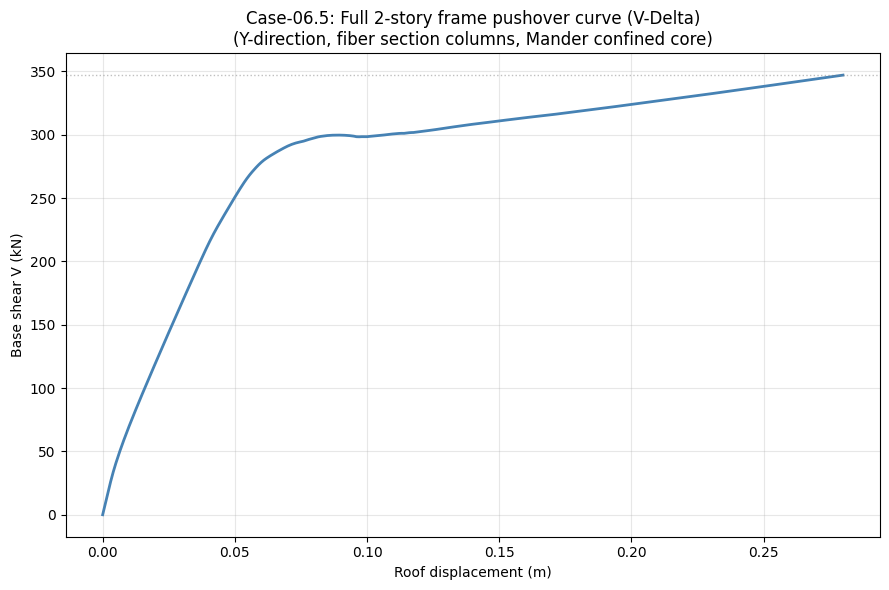

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9,6))
ax.plot(disps, base_shears, '-', color='steelblue', lw=2)
ax.axhline(base_shears.max(), color='gray', ls=':', lw=1, alpha=0.5)
ax.set_xlabel('Roof displacement (m)')
ax.set_ylabel('Base shear V (kN)')
ax.set_title('Case-06.5: Full 2-story frame pushover curve (V-Delta)\n(Y-direction, fiber section columns, Mander confined core)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 第 5 課:真正的 FEMA 273 等面積雙直線法——這次是 V-Δ,不是 M-φ

沿用上次修正過的正確聯立解方法(plateau 高度 $V_y$ 是解出來的,
不是直接假設等於峰值),這次套用在真正的結構 V-Δ 曲線上。

In [6]:
phi_u_idx = len(disps)-1   # 用推到的最終位移當"ultimate"(4% drift, 性能目標)
D_u, V_u = disps[phi_u_idx], base_shears[phi_u_idx]

D_trim, V_trim = disps[:phi_u_idx+1], base_shears[:phi_u_idx+1]
n_elastic = 8   # 用前幾步(明確在彈性段內)做初始勁度回歸
K0 = np.polyfit(D_trim[:n_elastic], V_trim[:n_elastic], 1)[0]
area_real = np.trapezoid(V_trim, D_trim)

# 正確聯立解(跟Case-06修正後的邏輯完全一致): Vy^2 - 2*K0*Du*Vy + 2*K0*area_real = 0
a_coef, b_coef, c_coef = 1.0, -2*K0*D_u, 2*K0*area_real
disc = b_coef**2 - 4*a_coef*c_coef
assert disc >= 0, "判別式應為正"
Vy1 = (-b_coef - disc**0.5)/(2*a_coef)
Vy2 = (-b_coef + disc**0.5)/(2*a_coef)
Vy = Vy1 if 0 < Vy1 < V_u else Vy2
Dy = Vy/K0

area_bilinear = Vy*D_u - Vy**2/(2*K0)
energy_diff = abs(area_bilinear-area_real)/area_real

print(f"K0(初始彈性勁度) = {K0:.2f} kN/m  <- 這才是真正的Keff(V-Delta意義下)")
print(f"降伏點: Dy = {Dy:.4f}m (drift={Dy/(h1+h2)*100:.2f}%), Vy = {Vy:.2f} kN")
print(f"性能目標點: Du = {D_u:.4f}m (drift={D_u/(h1+h2)*100:.2f}%), Vu = {V_u:.2f} kN")
print(f"延展性 mu = Du/Dy = {D_u/Dy:.2f}")
print(f"能量比對: 差異 {energy_diff:.2%}")

assert energy_diff < 0.01, "雙直線化面積誤差應幾乎為零"
print("\n[PASS] 真正的FEMA273等面積雙直線法(V-Delta)完成, 面積誤差幾乎為零")

K0(初始彈性勁度) = 8617.25 kN/m  <- 這才是真正的Keff(V-Delta意義下)
降伏點: Dy = 0.0351m (drift=0.50%), Vy = 302.33 kN
性能目標點: Du = 0.2800m (drift=4.00%), Vu = 347.03 kN
延展性 mu = Du/Dy = 7.98
能量比對: 差異 0.00%

[PASS] 真正的FEMA273等面積雙直線法(V-Delta)完成, 面積誤差幾乎為零


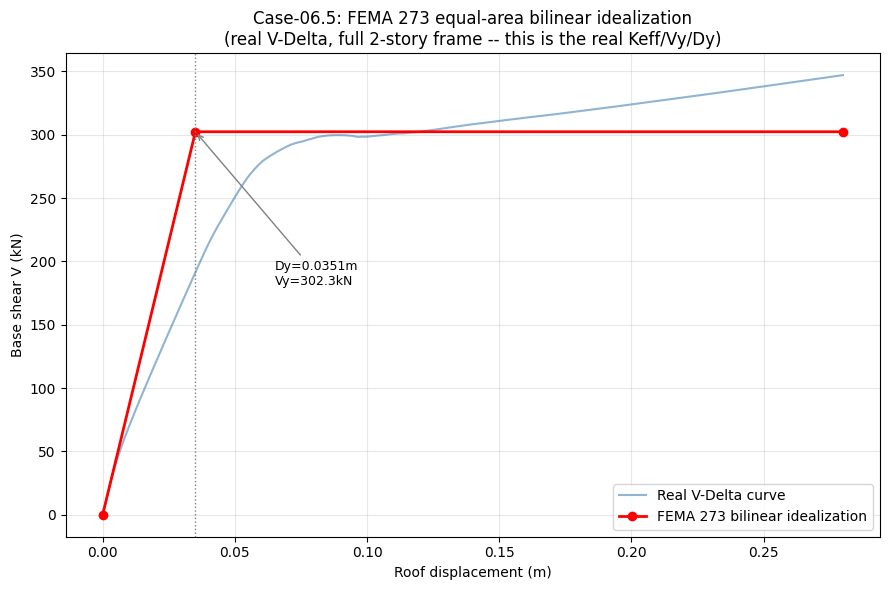

In [7]:
fig, ax = plt.subplots(figsize=(9,6))
ax.plot(disps, base_shears, '-', color='steelblue', lw=1.5, alpha=0.6, label='Real V-Delta curve')
ax.plot([0, Dy, D_u], [0, Vy, Vy], 'o-', color='red', lw=2, ms=6,
        label='FEMA 273 bilinear idealization')
ax.axvline(Dy, color='gray', ls=':', lw=1)
ax.annotate(f'Dy={Dy:.4f}m\nVy={Vy:.1f}kN', xy=(Dy,Vy), xytext=(Dy+0.03,Vy*0.6),
            fontsize=9, arrowprops=dict(arrowstyle='->',color='gray'))
ax.set_xlabel('Roof displacement (m)')
ax.set_ylabel('Base shear V (kN)')
ax.set_title('Case-06.5: FEMA 273 equal-area bilinear idealization\n(real V-Delta, full 2-story frame -- this is the real Keff/Vy/Dy)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 總結表

In [8]:
print("="*55)
print("Case-06.5 完整框架V-Delta側推 + FEMA273總結")
print("="*55)
print(f"{'K0(真正的Keff)':<24}{K0:.2f} kN/m")
print(f"{'Dy(降伏位移)':<24}{Dy:.4f} m ({Dy/(h1+h2)*100:.2f}% drift)")
print(f"{'Vy(降伏基底剪力)':<24}{Vy:.2f} kN")
print(f"{'Du(性能目標位移)':<24}{D_u:.4f} m ({D_u/(h1+h2)*100:.2f}% drift)")
print(f"{'延展性mu':<24}{D_u/Dy:.2f}")
print(f"{'與Case-04.5初始勁度差異':<24}{diff_pct:.1f}%")
print()
print("Case-06.5 [PASS] -- 完整2層樓框架V-Delta側推+真正FEMA273完成")
print("Case-06系列(纖維斷面驗證+完整框架側推)至此全部完成")

Case-06.5 完整框架V-Delta側推 + FEMA273總結
K0(真正的Keff)             8617.25 kN/m
Dy(降伏位移)                0.0351 m (0.50% drift)
Vy(降伏基底剪力)              302.33 kN
Du(性能目標位移)              0.2800 m (4.00% drift)
延展性mu                   7.98
與Case-04.5初始勁度差異        5.2%

Case-06.5 [PASS] -- 完整2層樓框架V-Delta側推+真正FEMA273完成
Case-06系列(纖維斷面驗證+完整框架側推)至此全部完成
